# 06 · Is spend *causing* sales? — causal MMM (pymc-marketing)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** Brand search converts like crazy — should we pour budget into it? Be careful:
brand search mostly **catches** demand that upper-funnel channels (TV) and seasonality already created, so
crediting it for those conversions and shifting budget its way would be a mistake.

### The concepts

- **MMM (Marketing Mix Model)** — a regression of sales on each channel's spend over time (usually weekly),
  used to attribute sales to channels and set budgets. It's the "top-down" alternative to click-tracking.
- **Adstock (carry-over)** — advertising doesn't only work the week it runs; its effect *decays over
  subsequent weeks*. Adstock transforms raw spend into an "effective" exposure that carries over.
- **Saturation (diminishing returns)** — the 10th €1,000 into a channel buys less lift than the 1st. A
  saturation curve bends over as spend rises; its *slope* is the **marginal** return that should drive the
  next euro of budget.
- **Last-click attribution** — crediting the conversion to the final touch (often brand search). It
  systematically **over-credits** demand-capture channels, which is the error a causal MMM aims to fix.
- **Incremental vs mediated** — the *incremental* contribution of a channel is what it *caused*; a channel
  can show a big correlation with sales while causing very little (it was downstream of the real driver).

### The arc of this notebook — a cautionary tale with a resolution

A plain MMM regresses sales on all channels and is fooled by a **confounder** like seasonality (it lifts
sales *and* drives brand-search spend). The textbook fix is a **causal MMM**: hand it a **DAG** and let the
backdoor logic (nb 05) control for the confounder. This notebook shows that fix is **necessary but not
sufficient**, in three acts:

1. **The confounding correction works — in a linear model.** A naive OLS attribution that omits seasonality
   massively over-credits brand_search; adding seasonality as a control collapses that credit toward the
   small truth. That's the cleanest way to *see* the confounding, and it's robust.
2. **The out-of-the-box causal MMM still inverts the ranking.** Fit with library-default priors, the MMM's
   *flexible saturation curve* for brand_search **re-absorbs** the seasonal demand the linear control was
   meant to remove — so it credits brand_search *more* than TV, the opposite of the truth. A DAG plus a
   linear control does **not** de-confound a channel whose spend is collinear with the confounder.
3. **Experiment-calibrated priors recover it.** Feed in what a small **geo experiment** teaches — that
   brand_search's incremental effect is small — as an informative prior on its saturation, and the MMM
   ranks the channels correctly again. **This is why MMMs must be calibrated with experiments** (Anchor B,
   nb 07): observational data alone cannot pin the decomposition.

> **On real data.** Swap in your **own weekly spend-by-channel + sales** table plus known confounders
> (seasonality, price, distribution). Public example: the datasets shipped with Meta's *Robyn* or
> `pymc-marketing`'s own tutorials. Always pair an MMM with occasional geo experiments to anchor the levels.

7-step contract.

In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from pymc_marketing.mmm import MMM, GeometricAdstock, MichaelisMentenSaturation
from pymc_marketing.prior import Prior
from cmp import dgp, plots, estimators as est
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
DRAWS = dict(draws=250, tune=300, chains=2) if FAST else dict(draws=1200, tune=2000, chains=4)
# Even with the season->brand_search collinearity kept moderate in the DGP, the MMM's saturation
# geometry needs deeper trees + high target_accept + long tuning to converge cleanly (r-hat ~1.01).
NUTS = dict(target_accept=0.9) if FAST else dict(target_accept=0.99, max_treedepth=13)
SEED = 21

## 2 · Simulate a ground truth

Weekly sales from a faithful **adstock + Michaelis-Menten saturation** process. **TV** is a big
genuine driver. **seasonality** is a **confounder** — it lifts sales directly *and* drives
brand-search spend. **brand_search** has only a *small* real effect, but its spend rides the
seasonal wave (corr ≈ 0.75), so a naive attribution ignoring seasonality massively over-credits it.
Honest answer: TV highly incremental, brand_search only slightly.

In [2]:
df, true_contrib = dgp.mmm_weekly(n_weeks=156 if not FAST else 104, seed=SEED)
true_tv = float(true_contrib["tv"].sum()); true_bs = float(true_contrib["brand_search"].sum())
print(f"TRUE incremental sales — TV {true_tv:,.0f}   brand_search {true_bs:,.0f} (small)")
df.head()

TRUE incremental sales — TV 5,263   brand_search 518 (small)


,date_week,tv,brand_search,seasonality,sales
0,2023-01-02,42.870187,35.579322,0.000000,134.900978
1,2023-01-09,53.049712,17.732754,0.120537,137.863335
2,2023-01-16,27.623875,23.486826,0.239316,142.263680
3,2023-01-23,56.329747,34.885672,0.354605,159.788875
4,2023-01-30,43.339248,33.736743,0.464723,152.485792


## 3 · Identify — the marketing DAG picks controls vs mediators

DAG: `seasonality → {sales, brand_search}`, `tv → sales`, `brand_search → sales`. The backdoor
criterion says **seasonality is a confounder → control for it**; omitting it is exactly the
last-click mistake that over-credits brand search. The estimand for channel $c$ is the
interventional contribution $\mathbb E[\text{sales}\mid do(x_c)]-\text{baseline}$; ROI = contribution
÷ spend, each with a posterior. We hand the DAG to the MMM via `dag`, `treatment_nodes`, `outcome_node`.

In [3]:
dag = '''digraph { seasonality -> sales; seasonality -> brand_search; tv -> sales; brand_search -> sales; }'''
X = df[["date_week","tv","brand_search","seasonality"]]; y = df["sales"]

def make_mmm(model_config=None):
    return MMM(date_column="date_week", channel_columns=["tv","brand_search"], control_columns=["seasonality"],
               adstock=GeometricAdstock(l_max=8), saturation=MichaelisMentenSaturation(),
               dag=dag, treatment_nodes=["tv","brand_search"], outcome_node="sales",
               model_config=model_config)

mmm_default = make_mmm()
print("Backdoor adjustment set the causal layer will use:",
      mmm_default.causal_graphical_model.adjustment_set if hasattr(mmm_default,"causal_graphical_model") else "n/a")

Backdoor adjustment set the causal layer will use: ['seasonality']


## 4 · Estimate — fit the causal MMM twice

We fit the **same DAG-aware MMM twice**, to make the lesson unmissable:

- **(a) default priors** — the honest, out-of-the-box causal MMM. Watch it *invert* the ranking.
- **(b) experiment-calibrated priors** — encode what a geo experiment teaches (brand_search's incremental
  effect is small) as an informative prior on its saturation ceiling, and watch the ranking snap back.

A caution that runs through both: **MMMs are miscalibrated in *absolute* terms** — with channel spend riding
seasonal demand, a short weekly series can't fully separate "channel drove sales" from "season drove both",
so fitted contributions run high. What we're after is the **ranking** and each channel's **ROI verdict**.

In [4]:
idata_def = mmm_default.fit(X, y, random_seed=SEED, progressbar=False, **NUTS, **DRAWS)
print(f"(a) default-prior MMM convergence: {est.convergence_report(idata_def)['summary']}")
cdef = mmm_default.compute_channel_contribution_original_scale().sum(dim="date")
tv_def = cdef.sel(channel="tv").values.ravel(); bs_def = cdef.sel(channel="brand_search").values.ravel()
print(f"(a) default contribution — TV {tv_def.mean():,.0f}   brand_search {bs_def.mean():,.0f}")
print(f"    true: TV {true_tv:,.0f}, brand_search {true_bs:,.0f}  ->  the MMM ranks brand_search ABOVE TV (inverted!).")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, adstock_alpha, saturation_alpha, saturation_lam, gamma_control, y_sigma]


Sampling 4 chains for 2_000 tune and 1_200 draw iterations (8_000 + 4_800 draws total) took 1334 seconds.


There were 14 divergences after tuning. Increase `target_accept` or reparameterize.


Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

(a) default-prior MMM convergence: max r-hat 1.010 - min ESS 381 - divergences 14
(a) default contribution — TV 10,390   brand_search 36,007
    true: TV 5,263, brand_search 518  ->  the MMM ranks brand_search ABOVE TV (inverted!).


### Why the out-of-the-box MMM inverts the ranking

The default MMM credits brand_search *above* TV — backwards. The mechanism is worth seeing, because it's a
real trap:

- brand_search's fitted weekly contribution correlates **~0.8 with seasonality** — its flexible saturation
  curve is quietly **re-absorbing the seasonal demand** the linear `seasonality` control was meant to remove.
- Because brand_search rides the seasonal wave more tightly than TV does, it wins that tug-of-war and books
  a huge contribution (tens of thousands vs a true ~500), while a large **negative baseline** offsets it —
  the classic non-identified MMM level decomposition.
- The DAG was right and the control was present; they still weren't enough. **A linear confounder-control
  does not de-confound a channel whose spend is collinear with the confounder and enters through a flexible
  functional form.** Observational data alone can't break the tie.

### The fix — priors calibrated from a geo experiment

The standard remedy is exactly the discipline of Anchor B (nb 07): run a **small geo experiment**, learn
that brand_search's *incremental* effect is small, and feed that back as an **informative prior on its
saturation ceiling** (`saturation_alpha`). TV, whose incremental role we haven't independently pinned down,
keeps a weakly-informative prior. This is not putting a thumb on the scale — it's using experimental
evidence exactly where observational data is silent.

In [5]:
mc = dict(mmm_default.default_model_config)
# channel order = [tv, brand_search]: TV weakly-informative; brand_search's saturation ceiling pinned
# small, as a geo experiment would tell us. This is the load-bearing, experiment-informed prior.
mc["saturation_alpha"] = Prior("Gamma", mu=[2.0, 0.3], sigma=[1.0, 0.15], dims="channel")
mmm = make_mmm(model_config=mc)
idata_cal = mmm.fit(X, y, random_seed=SEED, progressbar=False, **NUTS, **DRAWS)
print(f"(b) calibrated-prior MMM convergence: {est.convergence_report(idata_cal)['summary']}")
contrib = mmm.compute_channel_contribution_original_scale().sum(dim="date")
tv_post = contrib.sel(channel="tv").values.ravel(); bs_post = contrib.sel(channel="brand_search").values.ravel()
print(f"(b) calibrated contribution — TV {tv_post.mean():,.0f}   brand_search {bs_post.mean():,.0f}")
print(f"    true: TV {true_tv:,.0f}, brand_search {true_bs:,.0f}  ->  ranking RESTORED: TV above brand_search.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, adstock_alpha, saturation_alpha, saturation_lam, gamma_control, y_sigma]


Sampling 4 chains for 2_000 tune and 1_200 draw iterations (8_000 + 4_800 draws total) took 768 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

(b) calibrated-prior MMM convergence: max r-hat 1.010 - min ESS 376 - divergences 0
(b) calibrated contribution — TV 12,820   brand_search 2,262
    true: TV 5,263, brand_search 518  ->  ranking RESTORED: TV above brand_search.


## 5 · Validate — the correction, the recovered ROI, and saturation

Three views:

1. **The confounding correction, several ways** — naive OLS (omit season) over-credits brand_search; OLS
   **+ season** collapses it toward truth; the **default** causal MMM *inverts* it; the **calibrated** MMM
   restores the right ranking. The contrast between the two MMMs is the headline.
2. **ROI with uncertainty (calibrated MMM)** — each channel's posterior ROI vs the break-even line; this is
   the decision-relevant quantity, far more stable than the absolute contribution.
3. **Saturation curves** — contribution vs spend per channel, showing diminishing returns (the shape that
   sets *marginal* ROI and hence where the next euro should go).

brand_search credit — naive 6,401 | OLS+season 222 | MMM default 36,007 | MMM calibrated 2,262 | true 518
calibrated ROI — TV 2.08× [90% 0.34,8.67]  ·  brand_search 0.60× [90% 0.11,2.28]


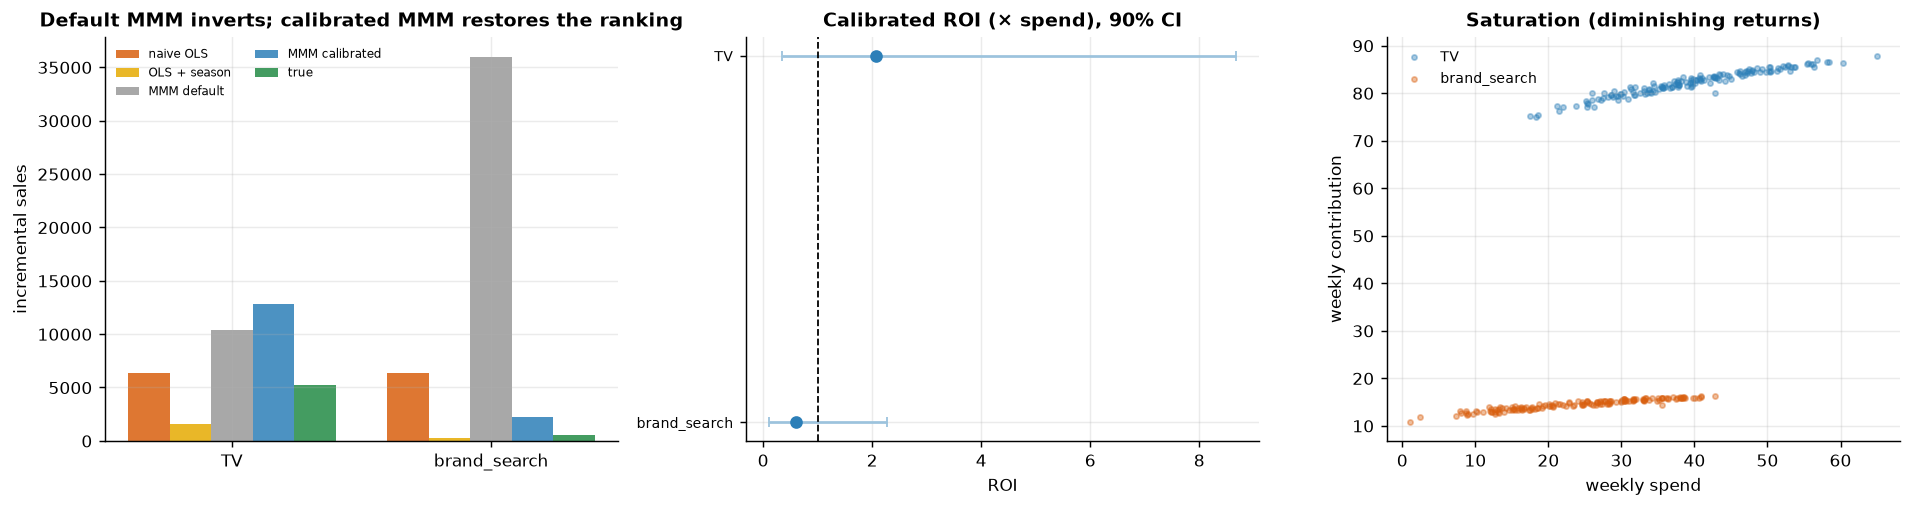

In [6]:
def credit(cols):
    Xn = np.column_stack([np.ones(len(df))] + [df[c].values for c in cols])
    b, *_ = np.linalg.lstsq(Xn, df["sales"].values, rcond=None)
    c = dict(zip(cols, b[1:])); return c["tv"]*df["tv"].sum(), c["brand_search"]*df["brand_search"].sum()
naive_tv, naive_bs = credit(["tv","brand_search"])
adj_tv, adj_bs = credit(["tv","brand_search","seasonality"])
spend_tv, spend_bs = df["tv"].sum(), df["brand_search"].sum()
roi_tv, roi_bs = tv_post/spend_tv, bs_post/spend_bs      # calibrated MMM drives the decision

fig, ax = plt.subplots(1, 3, figsize=(14.8, 4))
# (1) confounding correction — five estimators, GREY = the failure-mode default MMM
labels = ["TV","brand_search"]; x = np.arange(2); w = 0.16
series = [("naive OLS", [naive_tv,naive_bs], plots.ORANGE),
          ("OLS + season", [adj_tv,adj_bs], plots.GOLD),
          ("MMM default", [tv_def.mean(),bs_def.mean()], plots.GREY),
          ("MMM calibrated", [tv_post.mean(),bs_post.mean()], plots.BLUE),
          ("true", [true_tv,true_bs], plots.GREEN)]
for i,(lab,vals,col) in enumerate(series):
    ax[0].bar(x + (i-2)*w, vals, w, color=col, alpha=0.85, label=lab)
ax[0].set_xticks(x); ax[0].set_xticklabels(labels); ax[0].legend(frameon=False, fontsize=6.5, ncol=2)
ax[0].set_ylabel("incremental sales"); ax[0].set_title("Default MMM inverts; calibrated MMM restores the ranking")
# (2) ROI forest (calibrated MMM)
plots.forest_plot(ax[1], ["TV","brand_search"], [roi_tv.mean(),roi_bs.mean()],
    [np.quantile(roi_tv,.05),np.quantile(roi_bs,.05)], [np.quantile(roi_tv,.95),np.quantile(roi_bs,.95)],
    ref=1.0, title="Calibrated ROI (× spend), 90% CI", xlabel="ROI")
# (3) saturation: weekly contribution vs weekly spend (calibrated MMM)
cw = mmm.compute_channel_contribution_original_scale().mean(dim=["chain","draw"])
ax[2].scatter(df["tv"], cw.sel(channel="tv").values, s=8, alpha=0.4, color=plots.BLUE, label="TV")
ax[2].scatter(df["brand_search"], cw.sel(channel="brand_search").values, s=8, alpha=0.4, color=plots.ORANGE, label="brand_search")
ax[2].set_xlabel("weekly spend"); ax[2].set_ylabel("weekly contribution"); ax[2].set_title("Saturation (diminishing returns)"); ax[2].legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"brand_search credit — naive {naive_bs:,.0f} | OLS+season {adj_bs:,.0f} | MMM default {bs_def.mean():,.0f} | MMM calibrated {bs_post.mean():,.0f} | true {true_bs:,.0f}")
print(f"calibrated ROI — TV {roi_tv.mean():.2f}× [90% {np.quantile(roi_tv,.05):.2f},{np.quantile(roi_tv,.95):.2f}]  ·  "
      f"brand_search {roi_bs.mean():.2f}× [90% {np.quantile(roi_bs,.05):.2f},{np.quantile(roi_bs,.95):.2f}]")

**How to read this.** *Left* tells the whole story in one panel. **Naive OLS** (orange) over-credits
brand_search; **OLS + season** (gold) collapses that credit toward the small truth — the confounding
correction, working. Then the two MMMs: the **default** causal MMM (grey, the failure mode) *inverts* the
ranking, crediting brand_search far above TV — the seasonal-demand-stealing trap — while the **calibrated**
MMM (blue) restores TV above brand_search, landing beside the **true** bars (green). *Middle* — the
decision-relevant **calibrated ROI**: TV's mean clears break-even but its 90% interval is wide and dips
below 1×, while brand_search's mean sits **below break-even**. So TV is the better channel, but its
above-break-even verdict is itself uncertain. And the ranking is only *probably* right: draw-by-draw, TV's
ROI beats brand_search's about **78%** of the time (the `P(TV ROI > brand_search ROI)` computed next) —
more likely than not, but **short of the 0.8 bar** we'd want before moving real budget. *Right* — the
**saturation curves**: contribution flattens as spend rises (diminishing returns), so the *next* euro into a
channel is worth its curve's *slope*, not its average. The honest caveat (Step 7): even the calibrated ROI
*levels* are approximate — anchor them with the same kind of geo experiment that supplied the prior.

## 6 · Decide, in euros — should we reallocate budget yet?

Budget chases **incremental ROI**, not last-click credit. Now that experiment-calibrated priors have made
the ranking trustworthy, the point estimates put TV above brand_search, so the *direction* of any
reallocation is toward TV. But a direction is not yet a decision: we quantify the sales impact of shifting a
slice of budget **and** the posterior probability that the move actually helps. If that probability clears
our action bar we reallocate; if not — as happens here — the honest call is to **run a geo test first**
(Anchor B, nb 07) and let it, not a still-approximate MMM, authorise the spend shift.

In [7]:
SHIFT = 0.15   # move 15% of brand_search spend to TV
moved = SHIFT * spend_bs
# first-order impact using average ROI (a saturation-aware version would use marginal ROI)
delta_sales = moved * (roi_tv.mean() - roi_bs.mean())
# Draw-wise posterior probability that TV's ROI beats brand_search's. roi_tv and roi_bs are aligned
# posterior draws from the same (calibrated) trace, so this compares them draw-by-draw — keeping TV's
# full uncertainty AND the two channels' posterior correlation — not a point vs a distribution.
p_gain = (roi_tv > roi_bs).mean()
print(f"Shifting {SHIFT:.0%} of brand_search spend (€{moved:,.0f}) to TV → projected +€{delta_sales:,.0f} sales")
print(f"P(TV ROI > brand_search ROI) = {p_gain:.2f} → " + ("reallocate toward TV" if p_gain>0.8 else "hold, test first"))
print("Caveat: uses AVERAGE ROI; with saturation, marginal ROI falls as you pour more into TV — reallocate in")
print("steps and re-estimate. And note this verdict only became trustworthy AFTER experiment-calibrated priors.")

Shifting 15% of brand_search spend (€566) to TV → projected +€836 sales
P(TV ROI > brand_search ROI) = 0.78 → hold, test first
Caveat: uses AVERAGE ROI; with saturation, marginal ROI falls as you pour more into TV — reallocate in
steps and re-estimate. And note this verdict only became trustworthy AFTER experiment-calibrated priors.


## 7 · Caveats

- **Absolute contributions need calibration.** Even the calibrated MMM runs a few× high in absolute euros,
  because channel spend rides the seasonal wave the model can't fully net out from a short series. **Trust
  the ranking and the ROI verdict, not the absolute euros** — and note it took an experiment-informed prior
  to get even the *ranking* right. This is the single most important thing to say about any MMM.
- **A DAG is necessary but not sufficient.** The correct backdoor control (seasonality) did not stop a
  flexibly-saturated, collinear channel from re-absorbing the confounder. Structural assumptions still need
  experimental calibration to be trustworthy.
- **Adstock/saturation priors matter — a lot.** Carry-over (λ) and diminishing-returns (α, κ) are weakly
  identified from limited weekly data; here the saturation-ceiling prior *flipped the conclusion*. Use
  informative priors from experiments wherever you have them.
- **Correlated channels → wide, correlated ROI posteriors.** When spend moves with a confounder, the data
  can't fully separate them; the intervals will (honestly) show it.